<a href="https://colab.research.google.com/github/muqtadaend/Muqtada_2411531007_ML2526/blob/main/praktikum2/BernoulliNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Import needed libraries
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Dataset yang sudah diperbaiki (semua panjangnya 8)
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rainy',
                'rainy', 'rainy', 'overcast', 'sunny'],

    'Temperature': [85, 80, 83, 70, 68, 65, 64, 72],

    'Humidity': [85, 90, 78, 96, 80, 70, 65, 95],

    'Wind': [False, True, False, False, False, True, True, False],

    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No']
}

df = pd.DataFrame(dataset_dict)

df.head()

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85,85,False,No
1,sunny,80,90,True,No
2,overcast,83,78,False,Yes
3,rainy,70,96,False,Yes
4,rainy,68,80,False,Yes


<Axes: >

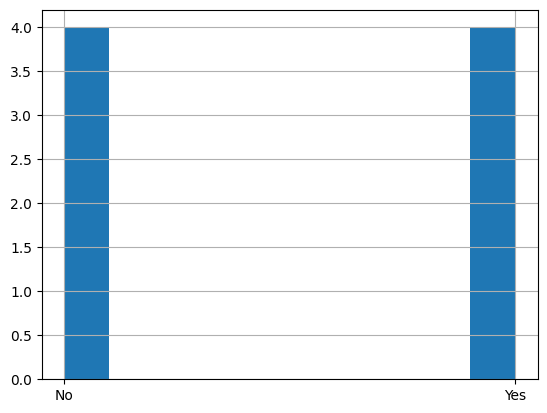

In [18]:
df['Play'].hist()

In [19]:
# ONE-HOT ENCODE 'Outlook' COLUMN
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

# CONVERT 'Windy' (bool) and 'Play' (binary) COLUMNS TO BINARY INDICATORS
df['Wind'] = df['Wind'].astype(int)
df['Play']=(df['Play'] == 'Yes').astype(int)

df.head()

,Temperature,Humidity,Wind,Play,overcast,rainy,sunny
0,85,85,0,0,0,0,1
1,80,90,1,0,0,0,1
2,83,78,0,1,1,0,0
3,70,96,0,1,0,1,0
4,68,80,0,1,0,1,0


In [20]:
# One-hot encode the categorized columns and drop them after
# Define categories for 'Temperature' and 'Humidity' for dataframe
df ['Temperature'] = pd.cut(df['Temperature'], bins=[0, 80, 100], labels=['Warm', 'Hot' ])
df['Humidity'] = pd.cut(df['Humidity'], bins=[0, 75, 100], labels=['Dry', 'Humid' ])

# One-hot encode the categorized columns
one_hot_columns = pd.get_dummies(df [['Temperature', 'Humidity' ]], drop_first=True, dtype=int)

# Drop the categorized columns from df
df = df.drop( ['Temperature', 'Humidity'], axis=1)

# Concatenate the one-hot encoded columns with the original DataFrames
df = pd. concat( [one_hot_columns, df], axis=1)

df.head()

,Temperature_Hot,Humidity_Humid,Wind,Play,overcast,rainy,sunny
0,1,1,0,0,0,0,1
1,0,1,1,0,0,0,1
2,1,1,0,1,1,0,0
3,0,1,0,1,0,1,0
4,0,1,0,1,0,1,0


In [21]:
# Split data into training and testing sets
X, y = df. drop(columns='Play' ), df ['Play' ]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=False)

In [22]:
# Train the model
nb_clf = BernoulliNB()
nb_clf.fit(X_train, y_train)

BernoulliNB()

Accuracy: 0.6666666666666666


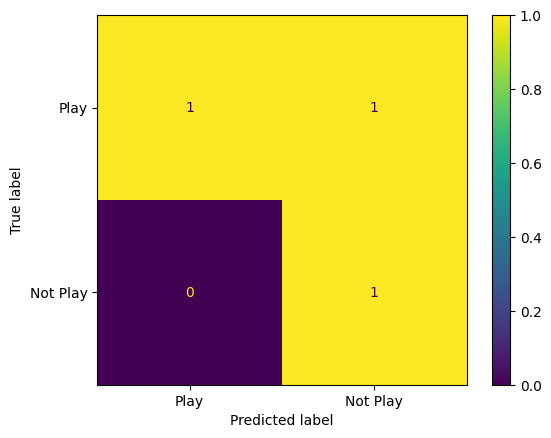

In [24]:
# Make predictions
y_pred = nb_clf.predict(X_test)

# Check accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred) }")

from sklearn.metrics import (
confusion_matrix,
ConfusionMatrixDisplay
)
labels = ["Play", "Not Play"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();